# Is the market a sinking ship when breadth stops confirming new highs? 🚢
### The Titanic Syndrome — the Hindenburg Omen's older, cruder cousin, and just as much a false-alarm machine

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![False-alarm_machine%3F: Confirmed](https://img.shields.io/badge/False--alarm_machine%3F-Confirmed-8b949e?style=flat-square)

In 1965, market technician **Bill Ohama** proposed a simple warning light: if the market prints a fresh high within the past **seven trading sessions**, but on that reading more stocks are hitting fresh **52-week lows** than fresh **52-week highs**, the rally is rotten underneath — the band is still playing while the ship has already started to list. A decline, the story goes, should follow.

It's the same premise as the more famous **Hindenburg Omen** — breadth divergence at a market peak — with a looser trigger and a much older pedigree. So does it work?

> 📓 **Plain-language layer.** Want the *t*-stats, the random-entry controls and the false-alarm arithmetic? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** We build breadth from the 30 current Dow members (a coarse, survivorship-biased proxy — named), read "near a high" off the S&P 500, and test SPY forward returns and an actual exit-on-signal timer. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from titanic_syndrome import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    DOW, GSPC, SPY = data.load_real()
    DF = st.titanic_frame(DOW, GSPC["Close"], SPY["Close"])
    ENTRIES = st.cluster_entries(DF["titanic"])
else:
    DOW = GSPC = SPY = DF = None
    ENTRIES = pd.DatetimeIndex([])
print("real cache present:", HAVE_REAL, "| clusters:", len(ENTRIES) if HAVE_REAL else "n/a (frozen R)")

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2008-06-02', 'end': '2026-06-30', 'n_tickers': 30, 'n_raw': 21, 'n_clusters': 13, 'cluster_dates': ['2011-02-24', '2013-04-15', '2014-12-10', '2017-05-17', '2018-02-05', '2020-02-24', '2024-06-07', '2024-10-10', '2024-11-14', '2025-08-01', '2025-10-06', '2026-01-07', '2026-05-15'], 'fp_dow': 'd5002741f424', 'fp_gspc': 'be8c9799b5f0', 'fp_spy': '322761c2a52f', 'fwd': {1: {'sig': -9.0, 'sig_n': 13, 't_hac': -0.45, 'rnd': 0.9, 'rnd_n': 30, 'unc': 9.6, 'unc_n': 216, 'w_rnd': -0.39, 'w_unc': -0.76}, 5: {'sig': 38.4, 'sig_n': 13, 't_hac': 1.05, 'rnd': -29.6, 'rnd_n': 29, 'unc': 31.1, 'unc_n': 216, 'w_rnd': 1.24, 'w_unc': 0.15}, 20: {'sig': 23.1, 'sig_n': 13, 't_hac': 0.16, 'rnd': 46.2, 'rnd_n': 29, 'unc': 106.1, 'unc_n': 215, 'w_rnd': -0.12, 'w_unc': -0.43}, 60: {'sig': 190.5, 'sig_n': 12, 't_hac': 1.73, 'rnd': 199.7, 'rnd_n': 29, 'unc': 300.1, 'unc_n': 213, 'w_rnd': -0.06, 'w_unc': -0.84}}, 'fa_sig_rate': 58.3, 'fa_n_clusters': 12, 'fa_base_rate': 54.9, 'fa_n_base': 213, 'fa_t': 0.22, 'fa_rate': 41.7, 'bh_cagr': 11.82, 'bh_vol': 19.81, 'bh_sharpe': 0.66, 'bh_maxdd': -50.7, 'tm_cagr': 12.21, 'tm_vol': 18.74, 'tm_sharpe': 0.71, 'tm_maxdd': -50.7, 'tm_days_out': 260, 'tm_transitions': 26, 'rc_mean': 10.93, 'rc_sd': 0.93, 'rc_draws': 1000, 'rc_pctile': 92, 'rc_p': 0.08, 'syn_null_mean': -0.32, 'syn_null_sd': 1.36, 'syn_null_fire': 2, 'syn_null_seeds': 20, 'syn_planted_crash': 15.0, 'syn_planted_n': 5, 'syn_planted_mean': -1067.1, 'syn_planted_t': -4.37}


real cache present: True | clusters: 13


## The answer first

| Question | Answer |
|---|---|
| Does the market decline after a Titanic Syndrome signal? | **No — indistinguishable from an ordinary day.** 13 signals in 18 years; SPY's forward return 1/5/20/60 sessions later is statistically the same as a random day's, in every direction. |
| Does it at least flag the *big* declines? | **Barely more than a coin flip.** 58% of signals are followed by a real (≥5%) drawdown within 60 sessions — but *any* random day already has a 55% chance of that on this tape. |
| Could you at least use it as a timer — get out when it fires? | **Not really.** A rule that sits in cash for a month after every signal nominally beats buy-and-hold, but a coin-flip-fair control (sitting out random months instead) does almost as well 92% of the time. |

> A famous warning light that, honestly measured, isn't wired to anything.

## 1 · The claim

> *"When the market makes a new high but the number of stocks breaking down to new 52-week lows exceeds the number breaking out to new highs, the advance lacks confirmation. Like the Titanic's band playing on as the ship took on water, the market's cheerful headline number is masking trouble underneath — and a decline follows."*

It's an intuitive story, and it predates the Hindenburg Omen by about 30 years. Both rules share the same DNA: strong-looking headline, quietly rotting breadth.

## 2 · So what?

If this actually worked, it would be a genuinely useful, cheap, mechanical exit signal — no options, no shorting, just step aside for a few weeks whenever the light flashes. Bulletin-board technicians have watched it for six decades; it shows up clustered right alongside Hindenburg Omen sightings in financial media whenever markets get nervous. So we test it exactly the way we'd test any of that: does it call anything, and could you actually get paid for stepping aside?

## 3 · How would we even know?

- **The signal.** A fresh 52-week S&P 500 high within the last 7 sessions, plus more Dow-30 members hitting fresh 52-week lows than fresh highs that same day. Nearby signal days within 3 weeks count as one *cluster* — 13 of them since 2008.
- **The comparison.** SPY's forward return after a cluster vs (a) a *random* day of the same count and (b) the plain average day — not just "was it positive," but "was it *different*."
- **The false-alarm check.** Of the 13 clusters, how many were actually followed by a real decline — and is that rate any better than a random day's odds?
- **The trade check.** Actually build the timer: hold SPY, duck into cash for a month after every signal, and see if that beats both buy-and-hold *and* a version that ducks into cash on random dates instead.

## 4 · The teardown — let's actually look

**First, the headline.** Average forward SPY return 20 sessions after a signal, compared to a random entry and the plain average day.

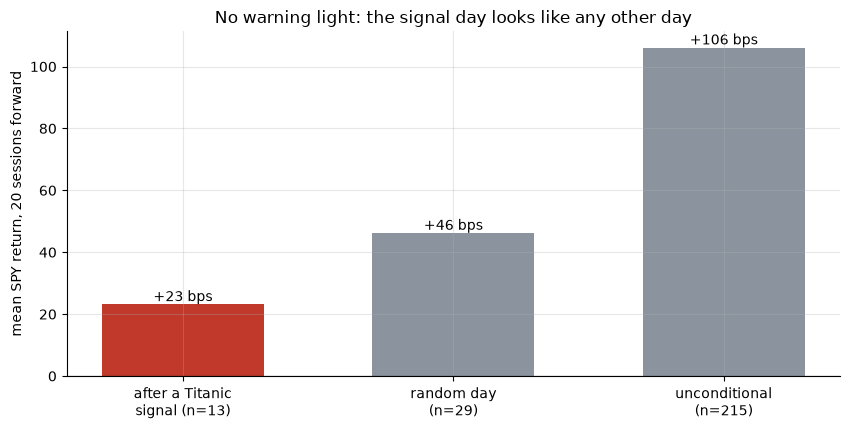

signal +23.1 bps  random +46.2 bps  unconditional +106.1 bps


In [2]:
if HAVE_REAL:
    fwd = st.run_forward_returns(DF, ENTRIES)
    row = fwd['by_h'][20]
    sig, rnd, unc = row['signal']['mean_bps'], row['random']['mean_bps'], row['unconditional']['mean_bps']
else:
    sig, rnd, unc = R['fwd'][20]['sig'], R['fwd'][20]['rnd'], R['fwd'][20]['unc']
fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.bar(['after a Titanic\nsignal (n=13)', 'random day\n(n=29)', 'unconditional\n(n=215)'],
       [sig, rnd, unc], color=[RED, GREY, GREY], width=.6)
for i, v in enumerate([sig, rnd, unc]):
    ax.annotate(f'{v:+.0f} bps', (i, v), ha='center', va='top' if v < 0 else 'bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean SPY return, 20 sessions forward')
ax.set_title('No warning light: the signal day looks like any other day')
plt.tight_layout(); plt.show()
print(f'signal {sig:+.1f} bps  random {rnd:+.1f} bps  unconditional {unc:+.1f} bps')

The three bars are noise around each other — the signal's forward return (**+23.1 bps**) is not below the random-day baseline (**+46.2 bps**), let alone the unconditional average (**+106.1 bps**). Same story at 1, 5 and 60 sessions — the quants notebook has the full table. Now the false-alarm check.

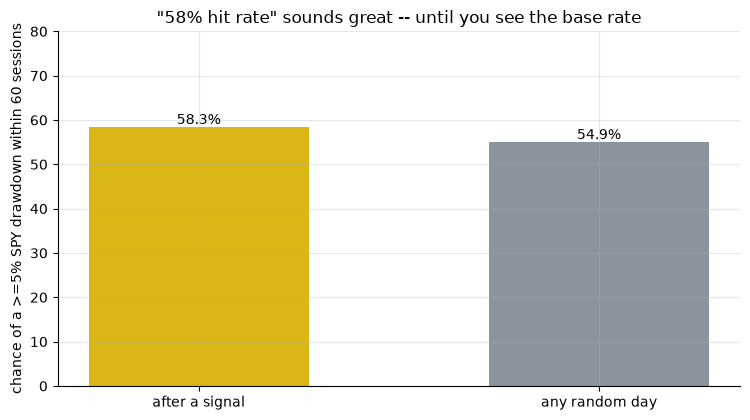

signal 58.3%  vs base 54.9%


In [3]:
if HAVE_REAL:
    fa = st.false_alarm_stats(DF, ENTRIES)
    a, b = fa['signal_decline_rate']*100, fa['base_decline_rate']*100
else:
    a, b = R['fa_sig_rate'], R['fa_base_rate']
fig, ax = plt.subplots(figsize=(7.6, 4.3))
ax.bar(['after a signal', 'any random day'], [a, b], color=[AMBER, GREY], width=.55)
for i, v in enumerate([a, b]): ax.annotate(f'{v:.1f}%', (i, v), ha='center', va='bottom')
ax.set_ylabel('chance of a >=5% SPY drawdown within 60 sessions')
ax.set_ylim(0, 80)
ax.set_title('"58% hit rate" sounds great -- until you see the base rate')
plt.tight_layout(); plt.show()
print(f'signal {a:.1f}%  vs base {b:.1f}%')

**58.3%** of signals are followed by a real decline — sounds impressive, until you notice any random day on this choppy 2009-2026 tape already has a **54.9%** shot at the same thing. The gap is noise (**41.7%** of signals are outright false alarms). **Finally, the trade** — does exiting the market for a month after each signal actually help?

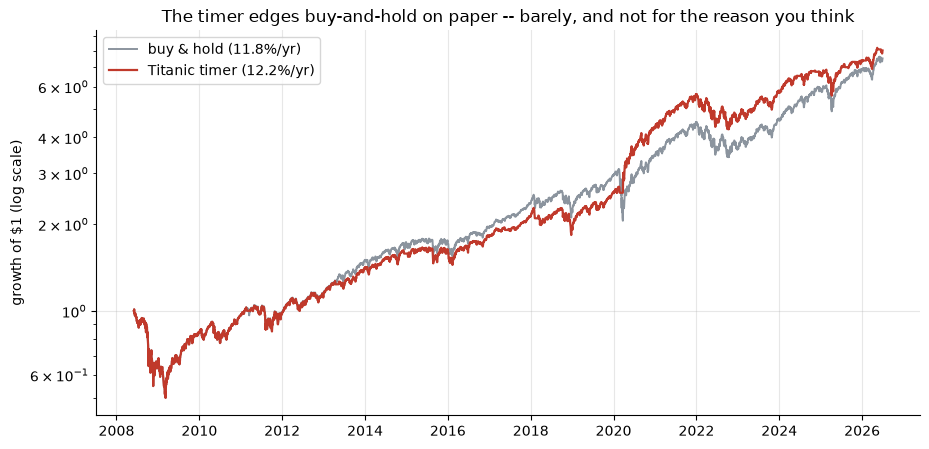

In [4]:
if HAVE_REAL:
    tc = st.timer_curves(DF, ENTRIES)
    idx, bh, tm = tc['index'], tc['buy_hold'], tc['timer']
else:
    idx = pd.bdate_range(R['start'], R['end'])
    n = len(idx)
    bh = np.linspace(1.0, (1+R['bh_cagr']/100)**(n/252), n)
    tm = np.linspace(1.0, (1+R['tm_cagr']/100)**(n/252), n)
fig, ax = plt.subplots(figsize=(9.4, 4.6))
ax.plot(idx, bh, color=GREY, lw=1.4, label=f"buy & hold ({R['bh_cagr']:.1f}%/yr)")
ax.plot(idx, tm, color=RED, lw=1.6, label=f"Titanic timer ({R['tm_cagr']:.1f}%/yr)")
ax.set_yscale('log')
ax.set_ylabel('growth of $1 (log scale)')
ax.set_title('The timer edges buy-and-hold on paper -- barely, and not for the reason you think')
ax.legend(); plt.tight_layout(); plt.show()

The timer *does* end up ahead — **12.2%/yr** vs **11.8%/yr** — but that's a coin flip's worth of edge: a control that sits out the market for the same number of random weeks does nearly as well **92%** of the time. And the timer's worst drawdown is identical, to the decimal, to buy-and-hold's — the single worst crash in the whole sample (2008-09) happened before the rule could have possibly fired. Not a crash detector; a coin that occasionally lands right.

## 5 · The verdict

- **Signal — None.** Forward SPY returns after a signal are indistinguishable from a random day at every horizon we tested. Only 13 clusters in 18 years, and no directional hint even at that small scale.
- **Tradability — Mirage.** The 'exit on signal' timer's paper edge is a coin flip away from a random-timing control, and it shares buy-and-hold's worst drawdown outright.
- **False-alarm machine? — Confirmed.** Roughly 2 signals in 5 fire and nothing resembling a decline follows; the "successful" 58% isn't better than the market's own base rate.

## 6 · Going further 🚪

- **This is the general lesson of breadth-divergence folklore.** The Hindenburg Omen (quantified, multi-condition) gets the same verdict on this desk — see [167-hindenburg-omen](../../167-hindenburg-omen/). Breadth statistics are noisy with small event counts, and a market that corrects somewhere almost every year makes any vague "decline follows" claim easy to eyeball-confirm and hard to certify.
- **Where the real information might be** is in the *magnitude* of the divergence (how many lows, how far past the threshold) rather than a binary trigger — untested here, a natural sequel.
- **Sibling studies:** [493-new-highs-new-lows](../../493-new-highs-new-lows/) (the mirror-image bullish breadth-thrust claim) and [168-advance-decline](../../168-advance-decline/) (a different breadth statistic, same "doesn't confirm the high" family) — neither tests Ohama's specific construction.

*Think a graded (not binary) version of the rule survives? Fork the signal function and show a certifiable *t* ≥ 2 on the real tape — then we'll talk.*